# OLIST Growth Analytics - Analysis

Run `python src/etl.py` first so `data/olist.db` exists.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/olist.db')

def run(sql_file):
    with open(sql_file) as f:
        return pd.read_sql_query(f.read(), conn)

## Q1: Funnel

,stage,orders_reached,pct_of_total
0,purchased,99441,100.00
1,approved,99281,99.84
2,shipped,97658,98.21
3,delivered,96476,97.02


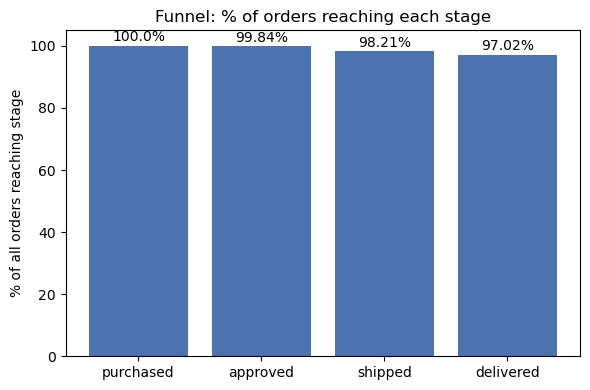

In [2]:
# Q1a: funnel - count of non-null orders per stage, and pct of all orders that reached it

funnel = run('../queries/funnel.sql')
display(funnel)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(funnel['stage'], funnel['pct_of_total'], color='#4C72B0')
ax.set_ylim(0, 105)
ax.set_ylabel('% of all orders reaching stage')
ax.set_title('Funnel: % of orders reaching each stage')
for i, pct in enumerate(funnel['pct_of_total']):
    ax.text(i, pct + 1.5, f'{pct}%', ha='center')
plt.tight_layout()
plt.show()

,from_stage,to_stage,from_count,to_count,pct_moved_to_next
0,created,approved,99441,99281,99.84
1,approved,shipped,99281,97658,98.37
2,shipped,delivered,97658,96476,98.79


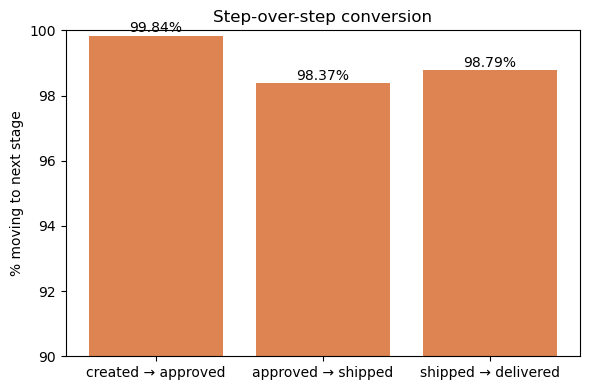

In [3]:
funnel_steps = run('../queries/step_funnel.sql')
display(funnel_steps)

labels = funnel_steps['from_stage'] + ' → ' + funnel_steps['to_stage']
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, funnel_steps['pct_moved_to_next'], color='#DD8452')
ax.set_ylim(90, 100)
ax.set_ylabel('% moving to next stage')
ax.set_title('Step-over-step conversion')
for i, pct in enumerate(funnel_steps['pct_moved_to_next']):
    ax.text(i, pct + 0.1, f'{pct}%', ha='center')
plt.tight_layout()
plt.show()


## Funnel Analysis Findings
The funnel is healthy overall — 97.0% of all 99,441 orders reach `delivered`, so there's no single
catastrophic drop-off stage. The step-by-step view below shows where the small amount of leakage
actually happens.

The biggest single-stage drop is approved → shipped (98.37%, 1.63pp lost) — larger than either
purchase → approval or shipped → delivered. That points to fulfillment/dispatch as the leakiest
handoff in the funnel, not payment approval or last-mile delivery.

## Q2: Cohort retention

,cohort_month,cohort_size,customers_active_month_1,retention_month_1_pct,customers_active_month_2,retention_month_2_pct
0,2016-09,4,0,0.00,0,0.00
1,2016-10,321,0,0.00,0,0.00
2,2016-12,1,1,100.00,0,0.00
3,2017-01,764,3,0.39,2,0.26
4,2017-02,1752,4,0.23,5,0.29
5,2017-03,2636,13,0.49,10,0.38
6,2017-04,2352,14,0.60,5,0.21
7,2017-05,3596,18,0.50,18,0.50
8,2017-06,3139,15,0.48,11,0.35
9,2017-07,3894,20,0.51,14,0.36


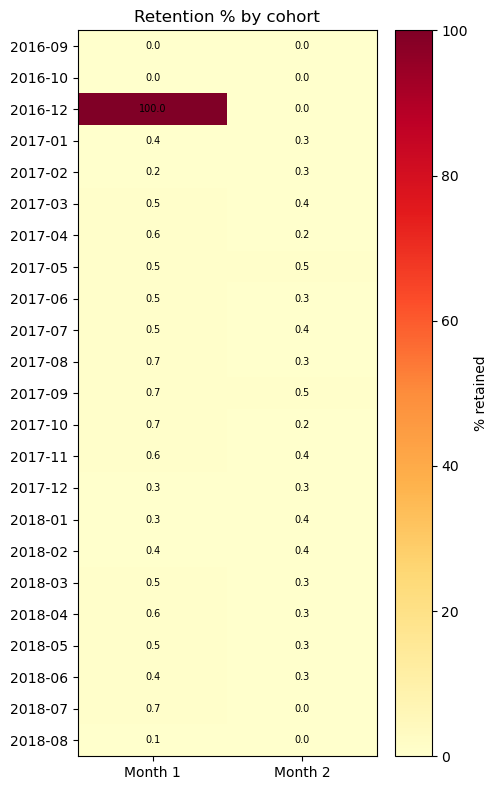

In [4]:
cohort_retention = run('../queries/cohort_retention.sql')
display(cohort_retention)

# pivot to a cohort_month x months_since_first_order grid and plot as a heatmap
heatmap_data = cohort_retention.set_index('cohort_month')[['retention_month_1_pct', 'retention_month_2_pct']]

fig, ax = plt.subplots(figsize=(5, 8))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Month 1', 'Month 2'])
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Retention % by cohort')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f'{heatmap_data.values[i, j]:.1f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='% retained')
plt.tight_layout()
plt.show()

## Cohort Retention Findings
Repeat purchase is essentially non-existent — month-1 retention sits under 1% for
almost every cohort, with no clear improvement across 2016–2018. This is a platform-wide loyalty
problem rather than a one-off bad cohort, and the biggest lever for growth here is repeat-purchase
incentives, not top-of-funnel acquisition. (2016-09 and 2016-12 have only 4 and 1 customers, so
their retention % is noise, not signal.)

## Q3: Payment / segment cut

,customer_state,avg_payment_val,num_orders,avg_payment_instals
0,SP,137.50,43622,2.6
1,PR,154.15,5262,2.9
2,ES,154.71,2107,3.0
3,MG,154.71,12102,3.0
4,RS,157.18,5668,3.0
5,RJ,158.53,13527,3.0
6,DF,161.13,2204,2.7
7,GO,165.76,2112,3.0
8,SC,165.98,3754,2.9
9,BA,170.82,3610,3.2


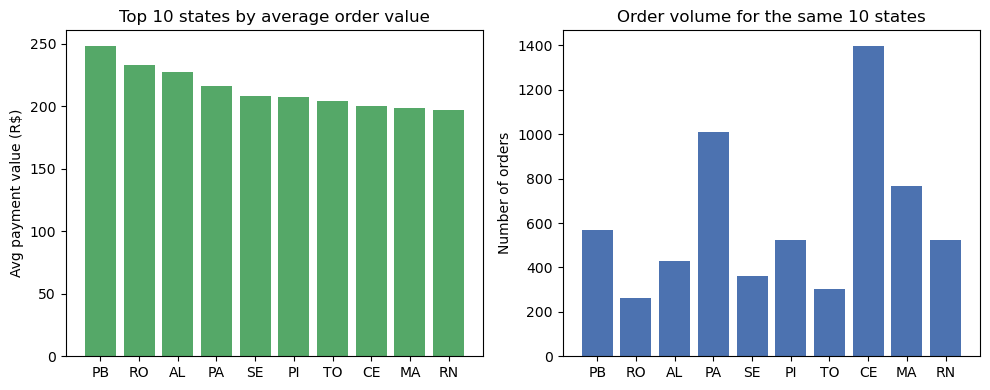

In [5]:
payment = run('../queries/payment_by_state.sql')
display(payment)

# bar charts of the top 10 states by avg payment value, alongside their order volume
top10 = payment.sort_values('avg_payment_val', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(top10['customer_state'], top10['avg_payment_val'], color='#55A868')
ax1.set_ylabel('Avg payment value (R$)')
ax1.set_title('Top 10 states by average order value')

ax2.bar(top10['customer_state'], top10['num_orders'], color='#4C72B0')
ax2.set_ylabel('Number of orders')
ax2.set_title('Order volume for the same 10 states')

plt.tight_layout()
plt.show()

## Payment segments findings:
SP — the highest-volume state by far (43,622 orders, ~44% of all orders) — has the
lowest average order value (R$137.50), while smaller, more remote states like PB, RO and AL have
the highest (R$225–250+), likely reflecting freight costs baked into `payment_value` for
longer-distance shipping. Installments, by contrast, are flat at ~3 across nearly every state, so
order value — not payment behaviour — is where states actually differentiate.